In [ ]:
!pip install sentence-transformers faiss-cpu langchain
!pip install pypdf langchain_community
!pip install langchain_text_splitters

In [ ]:
from google.colab import files
uploaded= files.upload()
for filename in uploaded.keys():
    print("uploaded:",filename)

Saving Microsoft 2025 Annual Report.pdf to Microsoft 2025 Annual Report (1).pdf
uploaded: Microsoft 2025 Annual Report (1).pdf


In [ ]:
# documents

from langchain_community.document_loaders import PyPDFLoader


In [ ]:
pdf_file = list(uploaded.keys())[0]
loader = PyPDFLoader(pdf_file)
documents = loader.load()
print("Number of pages loaded", len(documents))

Number of pages loaded 79


In [ ]:
print(documents[0]) # content in first page

page_content='Home
Shareholder Letter
Financial Review
Business
General
Operating Segments
Human Capital Resources
Operations
Research & Development
Distribution, Sales & Marketing
Licensing Options
Government Regulation
Available Information
Discussion & Analysis
Market Risk
Income Statements
Balance Sheets
Cash Flows Statements
Stockholders' Equity
Notes
Accounting Policies
Earnings Per Share
Other Income (Expense), Net
Investments
Derivatives
Property and Equipment
Business Combinations
Goodwill
Intangible Assets
Debt
Income Taxes
Unearned Revenue
Leases
Contingencies
Stockholders' Equity
Accumulated Other Comprehensive Income (Loss)
Employee Stock and Savings Plans
Segment Information & Geo Data
Auditor's Report
Controls & Procedures
Directors & Officers
Investor Relations
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
home  
8/31/26, 8:50 AM Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 1/79' metadata={'producer': 'Sk

In [ ]:
# chunking after ingestion
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
chunks= text_splitter.split_documents(documents)
print(len(chunks))

597


In [ ]:
print(chunks[0].page_content)

Home
Shareholder Letter
Financial Review
Business
General
Operating Segments
Human Capital Resources
Operations
Research & Development
Distribution, Sales & Marketing
Licensing Options
Government Regulation
Available Information
Discussion & Analysis
Market Risk
Income Statements
Balance Sheets
Cash Flows Statements
Stockholders' Equity
Notes
Accounting Policies
Earnings Per Share
Other Income (Expense), Net
Investments
Derivatives
Property and Equipment
Business Combinations
Goodwill


In [ ]:
print(chunks[1].page_content) ## same things last chunk repeated
## because of split

Investments
Derivatives
Property and Equipment
Business Combinations
Goodwill
Intangible Assets
Debt
Income Taxes
Unearned Revenue
Leases
Contingencies
Stockholders' Equity
Accumulated Other Comprehensive Income (Loss)
Employee Stock and Savings Plans
Segment Information & Geo Data
Auditor's Report
Controls & Procedures
Directors & Officers
Investor Relations
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
home  
8/31/26, 8:50 AM Microsoft 2025 Annual Report


In [ ]:
## embeddings from chunk
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
## 22 million parameter model

embedings = model.encode([chunk.page_content for chunk in chunks])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings = embedings
dimension = embeddings.shape[1]
index= faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))
print("Total vector in index", index.ntotal)
# equal to number of chunks

Total vector in index 597


how chunks look like

In [ ]:
print(dimension)

In [ ]:
import matplotlib.pyplot as plt
def visualise_embedding(vector, chunk_text=None , max_text_chars=500):
  vector= np.array(vector)
  normalized = (vector - np.min(vector)) / (np.max(vector) - np.min(vector))
  color_band = normalized.reshape(1,-1)
  if chunk_text is not None:
    print("chunk Text \n")
    print(chunk_text[:max_text_chars])

  plt.figure(figsize=(12,2))
  plt.imshow(color_band, aspect='auto', cmap='viridis')
  plt.yticks([])
  plt.xlabel(f'Embedding Dimension ({len(vector)})')
  plt.title('Vector Representation ')
  plt.show()

chunk Text 

must continue to think in decades but execute in quarters, approaching each day with the humility and
curiosity required to continuously improve, while being guided by our bold vision for the future.
Financially, it was a year of record performance. Revenue was $281.7 billion, up 15 percent. Operating income
grew 17 percent to $128.5 billion. And Azure surpassed $75 billion in revenue for the first time, up 34 percent.


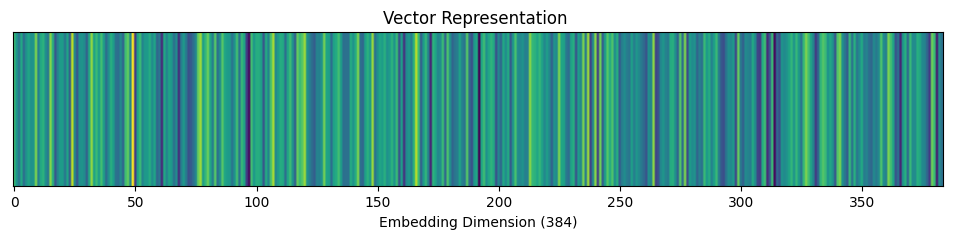

In [ ]:
visualise_embedding(embeddings[5], chunks[5].page_content)

Enter your question:how much profit did microsoft make in 2025 compare to 2024
chunk Text 

how much profit did microsoft make in 2025 compare to 2024


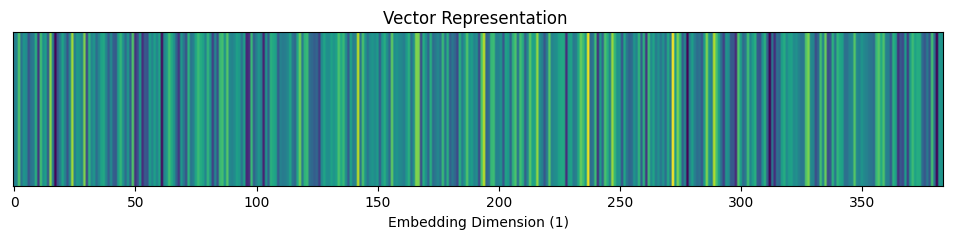

In [ ]:
query = input("Enter your question:")
query_embedding= model.encode([query])
visualise_embedding(query_embedding, query)
# goal of rag which color band is closest to which color band


In [ ]:
#
D,I = index.search(np.array(query_embedding),k=5)
retrieved_chunks = [chunks[i] for i in I[0]]

print("Top retrieved Chinks : \n")
for chunk in retrieved_chunks:
  print(chunk.page_content)
  print("Page",chunk.metadata["page"])

Top retrieved Chinks : 

Fiscal Year 2025 Compared with Fiscal Year 2024
Productivity and Business Processes
Revenue increased $14.0 billion or 13%.
Microsoft 365 Commercial products and cloud services revenue increased $10.8 billion or 14%.
Microsoft 365 Commercial cloud revenue grew 15% with Microsoft 365 Commercial seat growth of
6% driven by small and medium businesses and frontline worker offerings, as well as growth in
revenue per user. Microsoft 365 Commercial products revenue grew 7% driven by the Windows
Page 24
2023, respectively.
Stock-Based Compensation
Annual Report 2025
home  
8/31/26, 8:50 AM Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 43/79
Page 42
June 12, 2024 August 15, 2024 September 12, 2024 0.75 5,574
Total 3.00 22,295
The dividend declared on June 10, 2025 was included in other current liabilities as of June 30, 2025.
STOCK PERFORMANCE
COMPARISON OF 5 YEAR CUMULATIVE TOTAL RETURN*
Among Microsoft Corporation, the S&P 50

In [ ]:
## reranking for ordering kind of similarity search
## only for 5 chunks .. reranking while similarity search make it slow
## it produce score

from sentence_transformers import CrossEncoder

reranker= CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

pairs = [[query, chunk.page_content] for chunk in retrieved_chunks]
scores = reranker.predict(pairs)
print(scores)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[ 7.273022   -0.22580546  5.5564632   1.4395609  -0.4425104 ]


In [ ]:
ranked_chunks= sorted(
    zip(retrieved_chunks,scores), key=lambda x: x[1], reverse=True
)

print("After reranking \n")
for chunk, score in ranked_chunks:
  print("score:", score,)
  print(chunk.page_content)
  print("Page number: ", chunk.metadata["page"])
  print("==================")


After reranking 

score: 7.273022
Fiscal Year 2025 Compared with Fiscal Year 2024
Productivity and Business Processes
Revenue increased $14.0 billion or 13%.
Microsoft 365 Commercial products and cloud services revenue increased $10.8 billion or 14%.
Microsoft 365 Commercial cloud revenue grew 15% with Microsoft 365 Commercial seat growth of
6% driven by small and medium businesses and frontline worker offerings, as well as growth in
revenue per user. Microsoft 365 Commercial products revenue grew 7% driven by the Windows
Page number:  24
score: 5.5564632
June 12, 2024 August 15, 2024 September 12, 2024 0.75 5,574
Total 3.00 22,295
The dividend declared on June 10, 2025 was included in other current liabilities as of June 30, 2025.
STOCK PERFORMANCE
COMPARISON OF 5 YEAR CUMULATIVE TOTAL RETURN*
Among Microsoft Corporation, the S&P 500 Index and the NASDAQ Computer Index
Annual Report 2025
home  
8/31/26, 8:50 AM Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar

In [ ]:
# combine rerank chunk with context
top_chunks = [chunk.page_content for chunk, score in ranked_chunks[:3]]
context="\n\n".join(top_chunks)
print(context)

Fiscal Year 2025 Compared with Fiscal Year 2024
Productivity and Business Processes
Revenue increased $14.0 billion or 13%.
Microsoft 365 Commercial products and cloud services revenue increased $10.8 billion or 14%.
Microsoft 365 Commercial cloud revenue grew 15% with Microsoft 365 Commercial seat growth of
6% driven by small and medium businesses and frontline worker offerings, as well as growth in
revenue per user. Microsoft 365 Commercial products revenue grew 7% driven by the Windows

June 12, 2024 August 15, 2024 September 12, 2024 0.75 5,574
Total 3.00 22,295
The dividend declared on June 10, 2025 was included in other current liabilities as of June 30, 2025.
STOCK PERFORMANCE
COMPARISON OF 5 YEAR CUMULATIVE TOTAL RETURN*
Among Microsoft Corporation, the S&P 500 Index and the NASDAQ Computer Index
Annual Report 2025
home  
8/31/26, 8:50 AM Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 7/79

revenue for fiscal years 2025, 2024, or 2023. R

In [ ]:
!pip install groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.0 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
from groq import Groq

client = Groq(api_key=userdata.get("GROQ_API_KEY"))

models = client.models.list()

for model in models.data:
    print(model.id)



meta-llama/llama-prompt-guard-2-22m
canopylabs/orpheus-arabic-saudi
groq/compound-mini
qwen/qwen3.6-27b
whisper-large-v3
openai/gpt-oss-120b
whisper-large-v3-turbo
canopylabs/orpheus-v1-english
qwen/qwen3.8-27b
allam-2-7b
openai/gpt-oss-20b
openai/gpt-oss-safeguard-20b
meta-llama/llama-prompt-guard-2-86m
groq/compound


In [ ]:
query

'how much profit did microsoft make in 2025 compare to 2024'

In [ ]:
context

'Fiscal Year 2025 Compared with Fiscal Year 2024\nProductivity and Business Processes\nRevenue increased $14.0 billion or 13%.\nMicrosoft 365 Commercial products and cloud services revenue increased $10.8 billion or 14%.\nMicrosoft 365 Commercial cloud revenue grew 15% with Microsoft 365 Commercial seat growth of\n6% driven by small and medium businesses and frontline worker offerings, as well as growth in\nrevenue per user. Microsoft 365 Commercial products revenue grew 7% driven by the Windows\n\nJune 12, 2024 August 15, 2024 September 12, 2024 0.75 5,574\nTotal 3.00 22,295\nThe dividend declared on June 10, 2025 was included in other current liabilities as of June 30, 2025.\nSTOCK PERFORMANCE\nCOMPARISON OF 5 YEAR CUMULATIVE TOTAL RETURN*\nAmong Microsoft Corporation, the S&P 500 Index and the NASDAQ Computer Index\nAnnual Report 2025\nhome  \n8/31/26, 8:50 AM Microsoft 2025 Annual Report\nhttps://www.microsoft.com/investor/reports/ar25/index.html 7/79\n\nrevenue for fiscal years 20

In [ ]:
prompt = f"""
Answer the question using the context below.

Context:
{context}

Question:
{query}

Provide a concise answer.
If you don't find the information in the context, do not guess.
Say: "Information is not found in the document."
"""

response = client.chat.completions.create(
    model="qwen/qwen3.6-27b",
    messages=[
        {"role": "user", "content": prompt}
    ]
)

print(response.choices[0].message.content)



<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Question:** "how much profit did microsoft make in 2025 compare to 2024"
   - **Context Provided:** Snippets from a Microsoft financial report (Annual Report 2025). It mentions:
     - "Fiscal Year 2025 Compared with Fiscal Year 2024 Productivity and Business Processes"
     - "Revenue increased $14.0 billion or 13%."
     - Details on Microsoft 365 Commercial products/cloud services revenue increases.
     - Dividend information.
     - Stock performance comparison.
     - Geographic revenue classification table headers (no actual numbers provided in the snippet).
     - Metadata/headers/URLs.
   - **Key Constraint:** Use only the provided context. Be concise. If not found, say exactly: "Information is not found in the document."

2.  **Scan Context for Keywords:**
   - Keywords: "profit", "2025", "2024", "compare", "earnings", "net income"
   - Looking through the text: I see "Revenue increased $14.0 billion or 1

In [ ]:
## Another question 24:44 look

In [ ]:
## % sign is the usable in query = [% increase in price]